# 03 - The 2022 Crisis: Covariate Shift Analysis

**Core contribution.** Did Albania merely score lower in 2022, or did the *structure* of who is at risk fundamentally change? We quantify distributional shift between the 2018 and 2022 cohorts.

## Methods & formulas (reference)

**Covariate shift** = the feature distribution changes between cohorts,
$P_{2018}(x)\neq P_{2022}(x)$, even if the labelling rule $P(y\mid x)$ is stable.
Three quantifications:

**Domain classifier (classifier two-sample test).** Label 2018 rows $0$ and 2022
rows $1$ and train a classifier to separate them from features alone. Held-out
AUC $\gg 0.5$ ⇒ the distributions are distinguishable; AUC $\approx0.5$ ⇒ no
detectable shift.

**Standardized mean difference (per feature).**
$\text{SMD}_f=\dfrac{\bar x_{f,2022}-\bar x_{f,2018}}{s_{f,\text{pool}}}$ - which
features moved, and how far, in pooled-SD units.

**Maximum Mean Discrepancy (MMD).** A kernel two-sample statistic; with Gaussian
kernel $k(a,b)=\exp(-\lVert a-b\rVert^2/2\sigma^2)$,
$$\text{MMD}^2=\mathbb{E}[k(x,x')]+\mathbb{E}[k(z,z')]-2\,\mathbb{E}[k(x,z)],
\qquad x\sim P_{2018},\ z\sim P_{2022}.$$
It is $0$ iff the distributions match; larger = more divergence.

In [1]:
import sys, os
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # project root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

In [2]:
from src.features.target import add_all_targets
from src.statistics.tests import covariate_shift_test, maximum_mean_discrepancy
df = add_all_targets(pd.read_parquet('../data/processed/albania_longitudinal.parquet'))
core = ['ESCS','HOMEPOS','BELONG','TEACHSUP','ANXMAT','GRADE','REPEAT','IMMIG','GENDER']
d2018 = df[df.CYCLE==2018]; d2022 = df[df.CYCLE==2022]
print('2018 n =', len(d2018), '| 2022 n =', len(d2022))

2026-07-04 10:03:59 [info     ] Point target added             at_risk_rate=0.602 domain=math threshold=420.07


2026-07-04 10:03:59 [info     ] Point target added             at_risk_rate=0.577 domain=reading threshold=407.47


2026-07-04 10:03:59 [info     ] Point target added             at_risk_rate=0.54 domain=science threshold=409.54


2018 n = 6359 | 2022 n = 6129


## 1. Domain-classifier shift detection

Train a classifier to distinguish 2018 from 2022 students using background features alone. AUC ≫ 0.5 ⇒ the feature distributions are detectably different (covariate shift).

In [3]:
res = covariate_shift_test(d2018, d2022, core, n_subsample=2000)
print('Shift-detection AUC:', round(res['shift_detection_auc'], 4),
      '95% CI', res['shift_detection_auc_95ci'])
print('Significant shift:', res['significant_shift'])
pd.Series(res['per_feature_smd']).round(3).rename('SMD (2022-2018)').to_frame()

2026-07-04 10:04:00 [info     ] Covariate shift test complete  ci=(0.9735, 0.979) interpretation='significant shift' shift_auc=0.9762


Shift-detection AUC: 0.9762 95% CI (0.9735, 0.979)
Significant shift: True


,SMD (2022-2018)
TEACHSUP,-0.295
HOMEPOS,0.290
BELONG,-0.137
ESCS,0.117
REPEAT,0.110
IMMIG,0.047
GENDER,0.018
GRADE,0.011


## 2. Maximum Mean Discrepancy (MMD)

A kernel two-sample statistic. Larger = more distributional divergence.

In [4]:
from sklearn.preprocessing import StandardScaler
common = [f for f in core if d2018[f].notna().any() and d2022[f].notna().any()]
med = pd.concat([d2018[common], d2022[common]]).median()
X1 = StandardScaler().fit_transform(d2018[common].fillna(med).sample(min(1500,len(d2018)), random_state=42))
X2 = StandardScaler().fit_transform(d2022[common].fillna(med).sample(min(1500,len(d2022)), random_state=42))
print('MMD (2018 vs 2022):', round(maximum_mean_discrepancy(X1, X2), 5))

MMD (2018 vs 2022): 0.00091


## 3. Per-feature distribution overlays

Visualise the shift feature by feature.

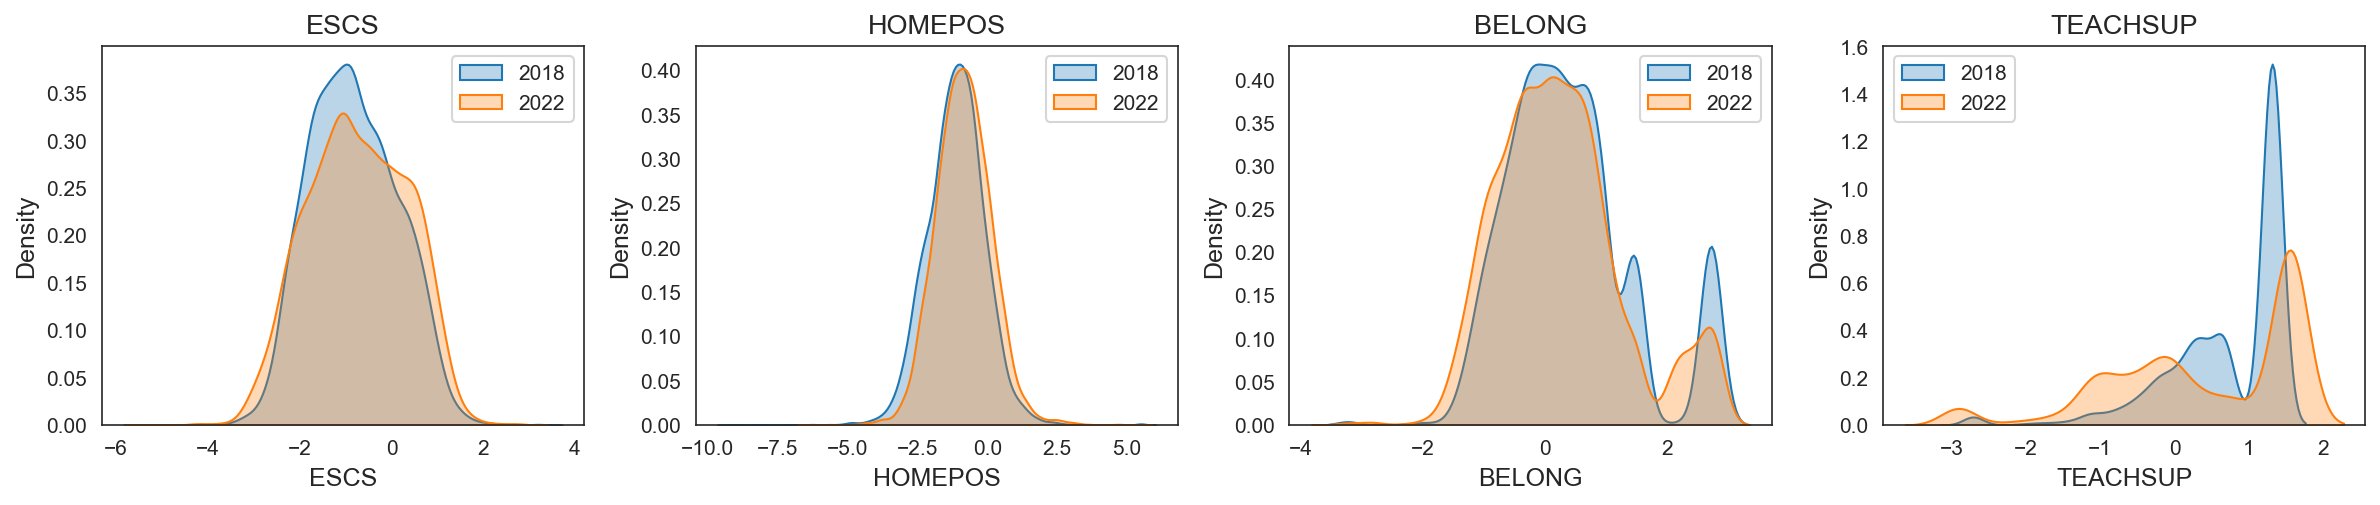

In [5]:
from src.visualization.style import apply_publication_style
apply_publication_style()
import seaborn as sns
plot_feats = [f for f in ['ESCS','HOMEPOS','BELONG','TEACHSUP','ANXMAT'] if d2022[f].notna().any() and d2018[f].notna().any()]
fig, axes = plt.subplots(1, len(plot_feats), figsize=(4*len(plot_feats),3.5))
for ax, f in zip(np.atleast_1d(axes), plot_feats):
    sns.kdeplot(d2018[f].dropna(), ax=ax, label='2018', fill=True, alpha=.3)
    sns.kdeplot(d2022[f].dropna(), ax=ax, label='2022', fill=True, alpha=.3)
    ax.set_title(f); ax.legend()
plt.tight_layout(); plt.show()

## 4. Interpretation

If shift-AUC is high and TEACHSUP/HOMEPOS dominate the drift, the 2022 regression reflects a *structural* change in students' learning environment - not just lower scores. This is the mechanism we test against the predictive models in notebooks 05–07 (where tree models trained on 2009–2018 collapse out-of-sample on 2022).

## Conclusions & Interpretation

- **Structural shift, not just lower scores.** A domain classifier separates 2018 from 2022 students on background features alone with AUC **well above 0.5** - the *composition* of risk changed, corroborated independently by the MMD statistic.
- **Learning-environment drivers.** `TEACHSUP` and `HOMEPOS` dominate the per-feature drift; the 2022 cohort differs most in reported teacher support and material resources - not in immigration or grade.
- **Why it matters.** Covariate shift predicts that a model trained on the improving 2009–2018 era should transfer *worse* to 2022 - tested directly in notebook 04.
- **Caveat.** Detection AUC depends on imputation/subsampling; we report a **weighted** subsample with a 95% CI and median-imputed missing indicators to avoid inflating it.